# 🛠️ Custom Dataset
---

- 🏗️ Build a multimodal custom dataset tailored for the Transformer model
- 🏆 Integrate the best-performing tokenizer as determined in: <br>
`Deep Learning/Hierachical Transformer/Dataset Tokenization/Evaluate Tokenization_opt/train_tokenizer.ipynb` <br>
which was `WordPiece`
- 🗂️ Uses the utility functions and the `CustomDataset` implementation located in: <br>
  `Deep Learning/Hierachical Transformer/Dataset Tokenization/Dataset Tokenization utils_opt/tokenization_utils.py`
  - 🧩 Implements all required utility functions for preprocessing and feature engineering.
  - 📝 Provides a modular and reusable `CustomDataset` class that integrates <br>
    these utilities for improved clarity, maintainability, and extensibility.
- ✅ Thoroughly test and validate the dataset implementation
---


### 🔤 Text Data

- **Tokenizer**: Utilizes a pre-trained WordPiece tokenizer, fine-tuned on the <br>
entire text corpus for domain-specific relevance. 
- **Tokenization**: Converts text columns into numerical token IDs, capturing <br>
semantic information.
- **Padding**: Sequences are uniformly padded to the maximum length observed <br>
across all text columns. This ensures consistent input dimensions for the Transformer.

### 🔢 Numerical and Categorical Data

- **📅 Datetime Decomposition**: Decomposes datetime columns into individual <br>
components (year, month, day, hour, minute, etc.) to extract granular temporal features.
- **📊 Initial Column Definition**:
    - Creates initial numerical columns, including parameter columns (ending with `_param`).
    - Creates initial categorical columns based on domain knowledge.
- **🔎 Feature Type Validation**:
    - Dynamically identifies numerical and categorical columns based on data characteristics.
    - Categorical columns are defined as those containing fewer than 10 unique values.
- **🗺️ Categorical Mapping**:
    -   Divides categorical columns into two types:
        - **Categorical Columns**: Directly used as categorical features.
        - **Mapping Categorical Columns**: Columns with values mapped to numerical indices.
            - Columns are designated as "mapping categorical" if their unique <br>
            values have a high average distance (over 100), indicating a <br>
            need for index-based representation.
- **Numerical Feature Normalization**: Numerical features are z-normalized <br>
to have a mean of 0 and a standard deviation of 1.
- **Categorical Feature Handling**: The overall minimum value is added to <br>
all categorical columns to ensure that all values are non-negative.

---
- Visualization of the process
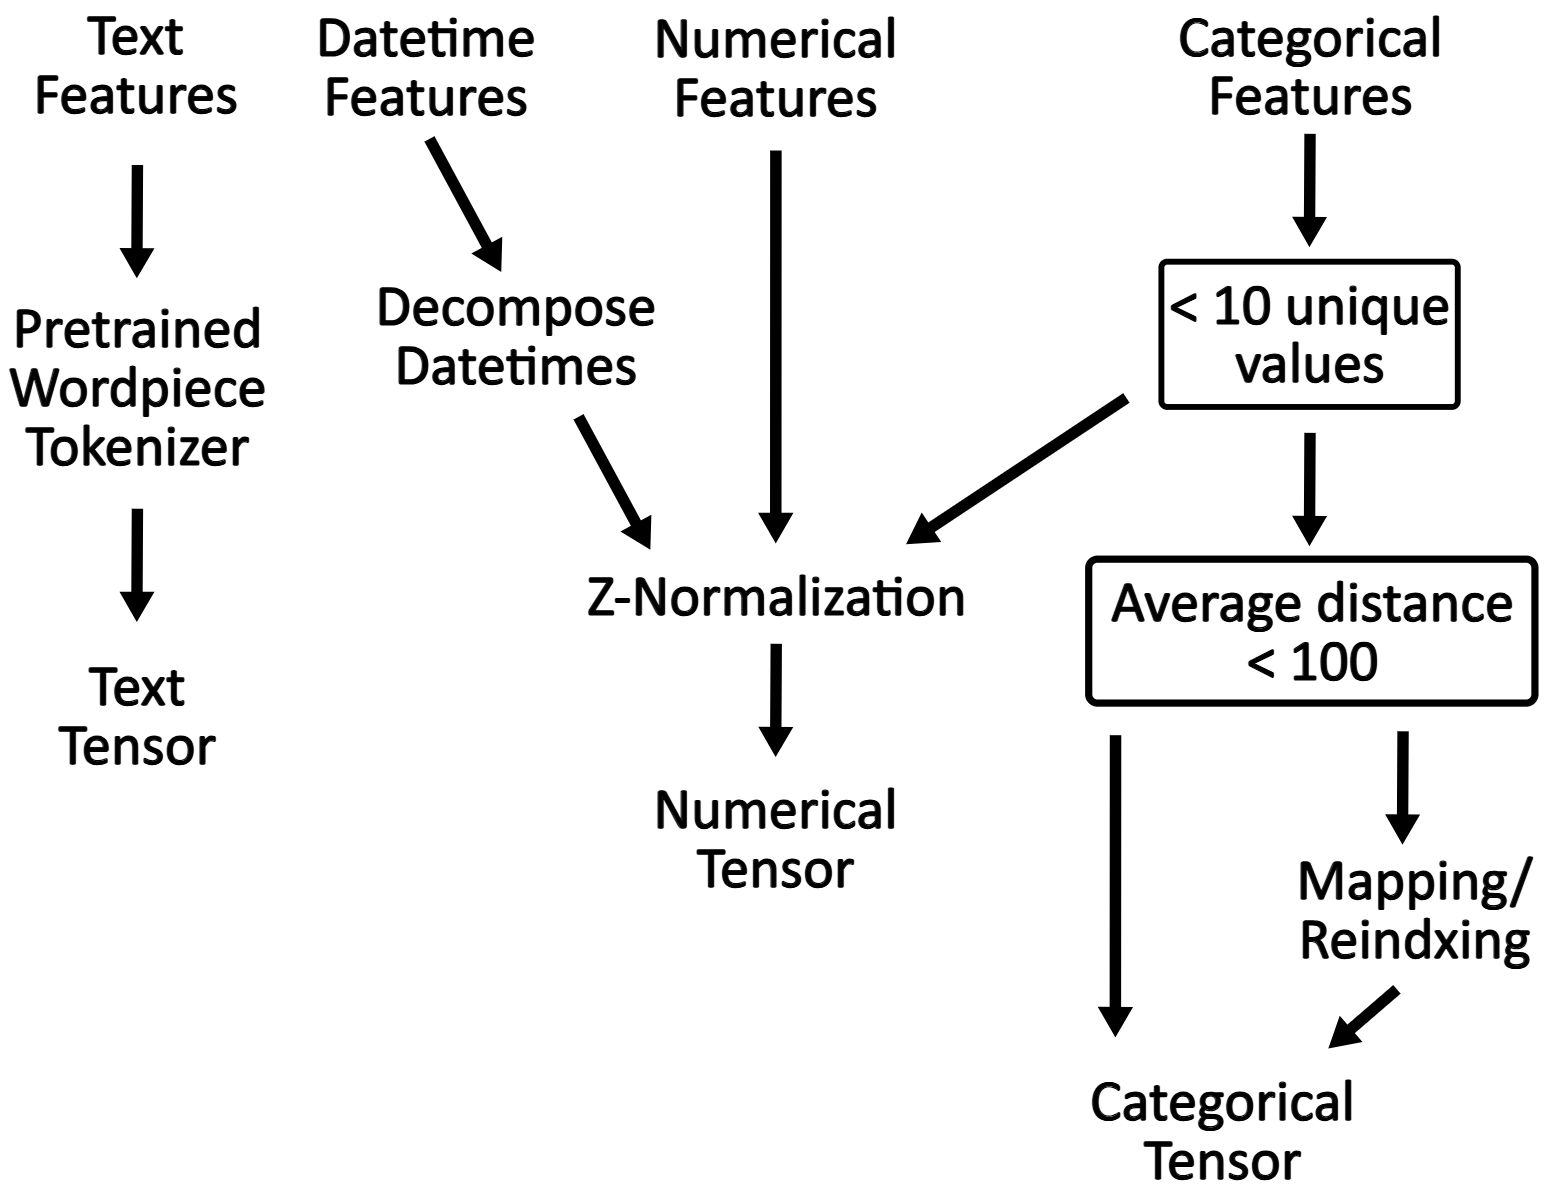

> ⚠️ For the Jupyter Notebook use only a small subsample of the data to verify the <br>
correctness of the code, else the Kernel will cras

In [ ]:
import os
import sys

# Get the current working directory
CWD = os.getcwd()

# Set a global random seed for reproducibility
RANDOM_SEED = 42

# Define the path to the local utils directory
LOCA_UTILS_DIR = os.path.normpath(os.path.join(CWD, "..", "Dataset Tokenization utils_opt"))
# Define the path to the global utils directory
GLOBAL_UTILS_DIR = os.path.normpath(
    os.path.join(CWD, "..", "..", "..", "..", "Global utils_opt")
)

# Append this directory to the system path
sys.path.append(LOCA_UTILS_DIR)
sys.path.append(GLOBAL_UTILS_DIR)


from global_utils import *
from dataset_tokenization_utils import *

# Enable autoreload and black formatting in Jupyter notebooks
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

✅ Found style_sheet_matplotlib.mplstyle at: /home/raraabf1/PhD/MRI_data_analysis/Stylesheets/style_sheet_matplotlib.mplstyle
✅ Found style_sheet_plotly.json at: /home/raraabf1/PhD/MRI_data_analysis/Stylesheets/style_sheet_plotly.json


In [ ]:
# Define the data directory path
DATA_DIR = os.path.normpath(
    os.path.join(
        CWD,
        "..",
        "..",
        "..",
        "..",
        "saved_datasets",
        "preprocessing",
    )
)

# Read in the raw MRI data from both pickle and parquet file
RAW_MRI_PKL_DF = data_read_in(DATA_DIR, "processed_mri_data.pkl")
RAW_MRI_PARQ_DF = data_read_in(DATA_DIR, "processed_mri_data.parquet")

# Create and rename necessary columns as ScanDuration_s_meas and ScanDuration_s_exam
RAW_MRI_PKL_DF = create_rename_columns(RAW_MRI_PKL_DF)
RAW_MRI_PARQ_DF = create_rename_columns(RAW_MRI_PARQ_DF)

# Perform filtering steps and plot the funnel chart for the filtering steps
# Filter out 0s and NaNs, exclude long examinations/measurements
FILTERED_MRI_PKL_DF, FILTERING_DICT = filter_dataframes(RAW_MRI_PKL_DF)
FILTERED_MRI_PARQ_DF, _ = filter_dataframes(RAW_MRI_PARQ_DF)


# Replace the Serial_scan values with the scanner names first
SCANNER_MAPPING = {
    69667: "AvantoFit (CRONA)",
    183811: "Sola (CRONA)",
    142185: "Aera (CRONA)",
    202017: "VidaFit (CRONA)",
    167008: "PrismaFit (CRONA)",
    75609: "Vida (CRONA)",
    142082: "Aera (UFK)",
}

# Apply the scanner mapping to both DataFrames using the Serial_scan column
MRI_PKL_DF = apply_scanner_mapping(
    df=FILTERED_MRI_PKL_DF,
    scanner_mapping=SCANNER_MAPPING,
    column="Serial_scan",
)
MRI_PARQ_DF = apply_scanner_mapping(
    df=FILTERED_MRI_PARQ_DF,
    scanner_mapping=SCANNER_MAPPING,
    column="Serial_scan",
)

# Apply the body region grouping to both DataFrames using the BodyRegion_meas column
MRI_PKL_DF = apply_bodyregion_grouping(MRI_PKL_DF, BODYREGION_GROUPING)
MRI_PARQ_DF = apply_bodyregion_grouping(MRI_PARQ_DF, BODYREGION_GROUPING)

# Sort the columns in both DataFrames first by suffix priority and then alphabetically
SUFFIX_PRIOTIRY = {"_scan": 0, "_exam": 1, "_meas": 2, "_param": 3, "_energy": 4}
MRI_PKL_DF = reorder_columns_by_suffix_priority(MRI_PKL_DF, SUFFIX_PRIOTIRY)
MRI_PARQ_DF = reorder_columns_by_suffix_priority(MRI_PARQ_DF, SUFFIX_PRIOTIRY)

1. Initial number of rows: 600293
2. Dropped 0 rows with NaN values.
3. Dropped 0 rows with 0 values.
4. Dropped 359 rows due to examination duration.
5. Dropped 402 rows due to measurement duration.
🧹 Filtered 761 rows from the DataFrame.
✅ Number of rows after filtering: 599532
1. Initial number of rows: 600293
2. Dropped 0 rows with NaN values.
3. Dropped 0 rows with 0 values.
4. Dropped 359 rows due to examination duration.
5. Dropped 402 rows due to measurement duration.
🧹 Filtered 761 rows from the DataFrame.
✅ Number of rows after filtering: 599532
⚠️ The following body regions are not mapped in BODYREGION_GROUPING and will be categorized as 'Other': {None}
⚠️ The following body regions are not mapped in BODYREGION_GROUPING and will be categorized as 'Other': {None}


In [3]:
# To run this notebook sample only 1000 rows, else the Kernel will crash.
# Sample indices from one DataFrame
sampled_indices = MRI_PKL_DF.sample(n=1000, random_state=RANDOM_SEED).index

# Use the same indices to sample both DataFrames
MRI_PKL_DF = MRI_PKL_DF.iloc[sampled_indices]
MRI_PARQ_DF = MRI_PARQ_DF[sampled_indices.tolist()]

## 🧩 Tokenization functions for CustomDataset

- 🔤 Tokenizes text columns using a pretrained tokenizer.
- 🚫 Replaces NaN values with a special `[NAN]` token.
- 🧼 Normalizes special characters before tokenization: <br>
  `,` and `;` become [SEP] <br>
  `_`, `%\`, `%/`, `%` becomes [SUBSEQ] <br>
  `/` becomes [SUB] <br>
  `+` becomes [AND] <br>
- 🔁 Converts numbered bracketed patterns such as `[/12]` or `[3]` into <br>
  `[REPEAT]12` and `[REPEAT]3` so repeated protocol fragments are handled consistently.
- 🧱 Pads sequences to the maximum length of the column.
- 🎭 Generates attention masks to indicate valid tokens.
- ✅ Ensures all text data is consistently formatted for transformer models.

In [1]:
# Define the path to the tokenizer file
TOKENIZER_PATH = os.path.normpath(
    os.path.join(CWD, "..", "Evaluate Tokenization_opt", "tokenizer_wordpiece.json")
)

# Load the tokenizer first
TOKENIZER = Tokenizer.from_file(TOKENIZER_PATH)

# Define the text columns to be encoded solely as input features
TEXT_COLUMNS = [
    "Machine_scan",
    "AllBodyRegions_exam",
    "BodyRegion_exam",
    # "LeanExaminationWoReps_exam",
    # "LeanExamination_exam",
    "Program_exam",
    "UsedAddins_exam",
    "Addin_meas",
    "AdjustmentType_meas",
    "BodyRegionGroup_meas",
    "BodyRegion_meas",
    "Coils_meas",
    "LeanProtocol_meas",
    # "License_meas",
    "Protocol_meas",
    "Sequence_meas",
]

# Encode the text columns
(
    TEXT_TOKENS_PAD_DICT,
    TEXT_MAPPINGS,
    TEXT_TOKENS_DF,
    NON_NAN_TEXT_DF,
    TEXT_MAX_LENGTH,
) = encode_text_columns(df=MRI_PKL_DF, text_columns=TEXT_COLUMNS, tokenizer=TOKENIZER)

NameError: name 'os' is not defined

## 🧮 Functions for Converting Numerical, Datetime, and Categorical Features

This section provides utility functions to preprocess numerical, datetime, and <br>
categorical features for the `CustomDataset`:

- **🗓️ Datetime decomposition:**  
  - Splits datetime columns into components (year, month, day, hour, minute, day <br>
  of week, day of year).

- **🔎 Feature Type Validation**:
    - Dynamically identifies numerical and categorical columns based on data characteristics.
    - Categorical columns are defined as those containing fewer than 10 unique values.
    
- **🗺️ Categorical Mapping**:
    -   Divides categorical columns into two types:
        - **🏷️ Categorical Columns**: Directly used as categorical features.
        - **🔢 Mapping Categorical Columns**: Columns with values mapped to numerical indices.
            - Columns are designated as "mapping categorical" if their unique <br>
            values have a high average distance (over 100), indicating a <br>
            need for index-based representation.

- **📏 Numerical Feature Normalization**: Numerical features are z-normalized <br>
to have a mean of 0 and a standard deviation of 1.
- **➕ Categorical Feature Handling**: The overall minimum value is added to <br>
all categorical columns to ensure that all values are non-negative.

In [5]:
# Define datetime columns to decompose
DATETIME_COLUMNS_DECOMPOSE = [
    "InstallDate_scan",
    "ExaminationStart_exam",
    "ExaminationEnd_exam",
    "MeasurementStart_meas",
    "MeasurementEnd_meas",
    "Date_energy",
]

# Apply datetime decomposition
DATETIME_DF, DATETIME_MAPPINGS, NON_NAN_DATETIME_DF = decompose_datetime_columns(
    df=MRI_PKL_DF,
    datetime_columns_decompose=DATETIME_COLUMNS_DECOMPOSE,
)

Decomposed InstallDate_scan into year, month, day, hour, minute, day_of_week, day_of_year components
Decomposed ExaminationStart_exam into year, month, day, hour, minute, day_of_week, day_of_year components
Decomposed ExaminationEnd_exam into year, month, day, hour, minute, day_of_week, day_of_year components
Decomposed MeasurementStart_meas into year, month, day, hour, minute, day_of_week, day_of_year components
Decomposed MeasurementEnd_meas into year, month, day, hour, minute, day_of_week, day_of_year components
Decomposed Date_energy into year, month, day, hour, minute, day_of_week, day_of_year components


In [6]:
# Identify numerical and categorical columns based on suffixes and initial lists
PARAMS_COLUMN = MRI_PKL_DF.columns[MRI_PKL_DF.columns.str.endswith("_param")].tolist()

# Define the initial lists of numerical and categorical columns based on domain knowledg
INITIAL_NUMERICAL_COLUMNS = [
    # Exam-level features
    "DurationTableMove_exam",
    "ExaminationID_exam",
    "FinalQATime_exam",
    "MaxShimTableDist_exam",
    "PreviousExaminationID_exam",
    "NumberOfShims_exam",
    "ScanDuration_s_exam",
    "TimeDoorCloseToMeasStart_exam",
    "TimeDoorOpenToExamEnd_exam",
    "TimeDoorOpened_exam",
    "TimeExamStartToDoorClose_exam",
    "TimeMeasEndToDoorOpen_exam",
    "TotalDoorClosedSpan_exam",
    "TurnaroundTime_exam",
    "WaitForStartOfSequenceTime_exam",
    # Measurement-level features
    "FK_EventID_meas",
    "MeasPrepDuration_meas",
    "MeasurementID_meas",
    "NoScanningTime_meas",
    "ScanDuration_s_meas",
    "SeqNumMeasPerExam_meas",
    "UOTperMeasurement_meas",
] + PARAMS_COLUMN

# Define the initial list of categorical columns based on domain knowledge
INITAL_CATEGORICAL_COLUMNS = [
    # Exam-level features
    "AdjustmentDidNotConverge_exam",
    "FaultyCoilDecrease_exam",
    "IsMultiStudy_exam",
    "NumberOfPatientRegister_exam",
    # Measurement-level features
    "HasMeasFailOrStop_meas",
    "HasPrepFailOrStop_meas",
    "HasSAREvent_meas",
    "HasSqueezeball_meas",
    "MeasFailOrStopCount_meas",
    "MeasStopPenaltyDuration_meas",
    "PrepFailOrStopCount_meas",
    "SqueezeBallCount_meas",
    # Too long for tokenization, so treat them as categorical features instead
    "LeanExaminationWoReps_exam",
    "LeanExamination_exam",
    "License_meas",
]


# Determine the final lists of numerical and categorical columns based on
# initial lists, and the datetime decomposition results
NUMERICAL_COLUMNS, CATEGORICAL_COLUMNS, MAPPING_CATEGORICAL_COLUMNS = (
    determine_num_cat_features(
        df=MRI_PKL_DF,
        initial_numerical_columns=INITIAL_NUMERICAL_COLUMNS,
        initial_categorical_columns=INITAL_CATEGORICAL_COLUMNS,
        datetime_df=DATETIME_DF,
    )
)

In [7]:
# Apply categorical mapping
CATEGORICAL_DF, CATEGORICAL_MAPPINGS, NON_NAN_CATEGORICAL_DF, categorical_min_val = (
    map_categorical_features(
        df=MRI_PKL_DF,
        categorical_columns=CATEGORICAL_COLUMNS,
        mapping_categorical_colummns=MAPPING_CATEGORICAL_COLUMNS,
    )
)

Mapping columns:   0%|          | 0/165 [00:00<?, ?it/s]

Column LeanExaminationWoReps_exam contains non-numeric values, keeping as object.
Column LeanExamination_exam contains non-numeric values, keeping as object.
Column License_meas contains non-numeric values, keeping as object.


In [8]:
# Z-normalize numerical features
(
    Z_NORMALIZED_NUMERICAL_DF,
    NUMERICAL_SCALERS,
    NUMERICAL_MAPPINGS,
    NON_NAN_NUMERICAL_DF,
) = z_normalize_numerical_features(
    df=MRI_PKL_DF,
    datetime_df=DATETIME_DF,
    numerical_columns=NUMERICAL_COLUMNS,
)

Selected numerical columns for normalization: ['B1 squared with MeasPause_param', 'B1 squared_param', 'Base resolution_param', 'Concats_param', 'Date_energy_Day', 'Date_energy_DayOfWeek', 'Date_energy_DayOfYear', 'Date_energy_Hour', 'Date_energy_Minute', 'Date_energy_Month', 'Date_energy_Year', 'DurationTableMove_exam', 'ExaminationEnd_exam_Day', 'ExaminationEnd_exam_DayOfWeek', 'ExaminationEnd_exam_DayOfYear', 'ExaminationEnd_exam_Hour', 'ExaminationEnd_exam_Minute', 'ExaminationEnd_exam_Month', 'ExaminationEnd_exam_Year', 'ExaminationID_exam', 'ExaminationStart_exam_Day', 'ExaminationStart_exam_DayOfWeek', 'ExaminationStart_exam_DayOfYear', 'ExaminationStart_exam_Hour', 'ExaminationStart_exam_Minute', 'ExaminationStart_exam_Month', 'ExaminationStart_exam_Year', 'FK_EventID_meas', 'FK_MeasurementID_param', 'FieldOfView_param', 'FinalQATime_exam', 'Flip Angle (array0)_param', 'Flip angle_param', 'ImagesPerSlab_param', 'InstallDate_scan_Day', 'InstallDate_scan_DayOfWeek', 'InstallDate_s

Normalizing columns:   0%|          | 0/106 [00:00<?, ?it/s]

In [9]:
# Label columns to normalize
LABEL_COLUMNS = [
    "TotalActivePower_KW_meas",
]

# Apply z-normalization for label columns
Z_NORMALIZED_NUMERICAL_DF, LABEL_SCALERS, LABEL_MAPPINGS, NON_NAN_LABEL_DF = (
    z_normalize_numerical_features(df=MRI_PKL_DF, label_columns=LABEL_COLUMNS)
)

Selected numerical columns for normalization: ['TotalActivePower_KW_meas']


Normalizing columns:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Z-inverse normalization for numerical features
Z_INVERSE_DF = inverse_normalize_features(Z_NORMALIZED_NUMERICAL_DF, NUMERICAL_SCALERS)

Skipping B1 squared with MeasPause_param: No scaler available (was single-value or all-NaN)
Skipping B1 squared_param: No scaler available (was single-value or all-NaN)
Skipping Base resolution_param: No scaler available (was single-value or all-NaN)
Skipping Concats_param: No scaler available (was single-value or all-NaN)
Skipping Date_energy_Day: No scaler available (was single-value or all-NaN)
Skipping Date_energy_DayOfWeek: No scaler available (was single-value or all-NaN)
Skipping Date_energy_DayOfYear: No scaler available (was single-value or all-NaN)
Skipping Date_energy_Hour: No scaler available (was single-value or all-NaN)
Skipping Date_energy_Minute: No scaler available (was single-value or all-NaN)
Skipping Date_energy_Month: No scaler available (was single-value or all-NaN)
Skipping Date_energy_Year: No scaler available (was single-value or all-NaN)
Skipping DurationTableMove_exam: No scaler available (was single-value or all-NaN)
Skipping ExaminationEnd_exam_Day: No scal

In [11]:
# Ensure that the inverse normalized DataFrame is approximately equal to the
# original non-normalized numerical DataFrame
assert np.allclose(
    Z_INVERSE_DF.values,
    Z_NORMALIZED_NUMERICAL_DF.values,
    atol=1e-6,
), "Inverse normalization did not accurately recover the original numerical values."

## 🔗 Concatenation of DataFrames

In [12]:
# Concatenate the numerical, datetime, and categorical DataFrames
CONCATENATED_DF, UPDATED_MAPPINGS = concatenate_dataframes(
    df_list=[Z_NORMALIZED_NUMERICAL_DF, TEXT_TOKENS_DF, CATEGORICAL_DF],
    mappings=[NUMERICAL_MAPPINGS, TEXT_MAPPINGS, CATEGORICAL_MAPPINGS],
)

Concatenated DataFrame with 179 columns.
Updated mappings with 284 columns.


## 🧩 CustomDataset

The `CustomDataset` is a PyTorch-compatible dataset class tailored for <br>
multimodal MRI data, facilitating transformer-based deep learning workflows. <br>
It integrates and preprocesses various feature types to optimize model performance:

- **🔤 Text Features**:  
    - Text columns are tokenized using a fine-tuned WordPiece tokenizer.
    - NaN values are replaced with a special [NAN] token, and sequences are <br>
      padded for consistent length. 
    - Special characters are normalized before tokenization: `,` and `;` become [SEP], <br>
       `_`, `%\`, `%/`, `%` becomes [SUBSEQ],`/` becomes [SUB], `+` becomes [AND]
    - Numbered bracketed patterns such as `[/12]` or `[3]` are converted to <br>
      `[REPEAT]12` and `[REPEAT]3` so repeated protocol fragments are handled consistently. 
    - Attention masks distinguish valid tokens from padding.

- **📅 Datetime Features**: Datetime columns are decomposed into components <br>
(year, month, day, etc.) to capture temporal patterns.

- **🔢 Numerical Features**: Numerical and datetime-derived features are <br>
z-normalized to ensure consistent scaling.


- **📊 Categorical Features**:
    - Categorical features are divided into:
        - **Categorical Columns**: Directly used as categorical features.
        - **Mapping Categorical Columns**: Values are mapped to numerical <br>
        indices for efficient processing.
    - The overall minimum value is added to ensure non-negative values.

- **🎯 Label Features**: Label columns are z-normalized to standardize the target variable.

- **🎭 Attention Masks**: Missing or padded values are tracked with masks so <br>
  the model can distinguish valid entries from placeholders.

**Each sample returned by the dataset consists of eight tensors:**

1.  IDX of the original dataframe
2.  Numerical features
3.  Text features (tokenized ids)
4.  Categorical features
5.  Label features
6.  Numerical mask
7.  Text attention mask
8.  Categorical Mask
9.  Label Mask

This structure enables flexible batching, masking, and multimodal input <br>
handling, optimizing transformer model training for MRI data analysis.

In [13]:
# Create the dataset with all parameters
DATASET = CustomDataset(
    data=MRI_PKL_DF,
    tokenizer=TOKENIZER,
    text_columns=TEXT_COLUMNS,
    datetime_columns_decompose=DATETIME_COLUMNS_DECOMPOSE,
    initial_numerical_columns=INITIAL_NUMERICAL_COLUMNS,
    initial_categorical_columns=INITAL_CATEGORICAL_COLUMNS,
    label_columns=LABEL_COLUMNS,
)

Pad token ID: 0
NaN token ID: 1

Step 1: Computing maximum lengths and initial encodings...


Encoding columns:   0%|          | 0/13 [00:00<?, ?it/s]

  Machine_scan: length=4, start_idx=0, end_idx=4
  AllBodyRegions_exam: length=5, start_idx=4, end_idx=9
  BodyRegion_exam: length=1, start_idx=9, end_idx=10
  Program_exam: length=24, start_idx=10, end_idx=34
  UsedAddins_exam: length=5, start_idx=34, end_idx=39
  Addin_meas: length=1, start_idx=39, end_idx=40
  AdjustmentType_meas: length=1, start_idx=40, end_idx=41
  BodyRegionGroup_meas: length=3, start_idx=41, end_idx=44
  BodyRegion_meas: length=1, start_idx=44, end_idx=45
  Coils_meas: length=32, start_idx=45, end_idx=77
  LeanProtocol_meas: length=13, start_idx=77, end_idx=90
  Protocol_meas: length=15, start_idx=90, end_idx=105
  Sequence_meas: length=13, start_idx=105, end_idx=118

Overall maximum length across all columns: 118

Step 2: Processing encodings with padding and mask generation...


Processing encodings:   0%|          | 0/13 [00:00<?, ?it/s]

  Machine_scan: 1000 rows encoded with max_length=4
  AllBodyRegions_exam: 1000 rows encoded with max_length=5
  BodyRegion_exam: 1000 rows encoded with max_length=1
  Program_exam: 1000 rows encoded with max_length=24
  UsedAddins_exam: 1000 rows encoded with max_length=5
  Addin_meas: 1000 rows encoded with max_length=1
  AdjustmentType_meas: 1000 rows encoded with max_length=1
  BodyRegionGroup_meas: 1000 rows encoded with max_length=3
  BodyRegion_meas: 1000 rows encoded with max_length=1
  Coils_meas: 1000 rows encoded with max_length=32
  LeanProtocol_meas: 1000 rows encoded with max_length=13
  Protocol_meas: 1000 rows encoded with max_length=15
  Sequence_meas: 1000 rows encoded with max_length=13
Decomposed InstallDate_scan into year, month, day, hour, minute, day_of_week, day_of_year components
Decomposed ExaminationStart_exam into year, month, day, hour, minute, day_of_week, day_of_year components
Decomposed ExaminationEnd_exam into year, month, day, hour, minute, day_of_wee

Mapping columns:   0%|          | 0/165 [00:00<?, ?it/s]

Column LeanExaminationWoReps_exam contains non-numeric values, keeping as object.
Column LeanExamination_exam contains non-numeric values, keeping as object.
Column License_meas contains non-numeric values, keeping as object.
Selected numerical columns for normalization: ['B1 squared with MeasPause_param', 'B1 squared_param', 'Base resolution_param', 'Concats_param', 'Date_energy_Day', 'Date_energy_DayOfWeek', 'Date_energy_DayOfYear', 'Date_energy_Hour', 'Date_energy_Minute', 'Date_energy_Month', 'Date_energy_Year', 'DurationTableMove_exam', 'ExaminationEnd_exam_Day', 'ExaminationEnd_exam_DayOfWeek', 'ExaminationEnd_exam_DayOfYear', 'ExaminationEnd_exam_Hour', 'ExaminationEnd_exam_Minute', 'ExaminationEnd_exam_Month', 'ExaminationEnd_exam_Year', 'ExaminationID_exam', 'ExaminationStart_exam_Day', 'ExaminationStart_exam_DayOfWeek', 'ExaminationStart_exam_DayOfYear', 'ExaminationStart_exam_Hour', 'ExaminationStart_exam_Minute', 'ExaminationStart_exam_Month', 'ExaminationStart_exam_Year', 

Normalizing columns:   0%|          | 0/106 [00:00<?, ?it/s]

Selected numerical columns for normalization: ['TotalActivePower_KW_meas']


Normalizing columns:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
(
    IDX_DF,
    NUMERICAL_TENSOR,
    CATEGORICAL_TENSOR,
    TEXT_TENSOR,
    LABEL_TENSOR,
    NUMERICAl_ATTENTION_MASK,
    CATEGORICAL_ATTENTION_MASK,
    TEXT_ATTENTION_MASK,
    LABEL_ATTENTION_MASK,
) = DATASET[123]

In [15]:
print(f"Max numerical length: {DATASET.max_numerical_length}")
print(f"Max text length: {DATASET.max_text_length}")
print(f"Max categorical length: {DATASET.max_categorical_length}")

Max numerical length: 106
Max text length: 118
Max categorical length: 165


In [16]:
print(f"Numerical mapping: {DATASET.numerical_mappings}")
print(f"Text mapping: {DATASET.text_mappings}")
print(f"Categorical mapping: {DATASET.categorical_mappings}")

Numerical mapping: {'B1 squared with MeasPause_param': {'start_idx': 0, 'end_idx': 1, 'length': 1, 'normalized_column': 'B1 squared with MeasPause_param', 'scaler': StandardScaler(), 'has_scaler': True}, 'B1 squared_param': {'start_idx': 1, 'end_idx': 2, 'length': 1, 'normalized_column': 'B1 squared_param', 'scaler': StandardScaler(), 'has_scaler': True}, 'Base resolution_param': {'start_idx': 2, 'end_idx': 3, 'length': 1, 'normalized_column': 'Base resolution_param', 'scaler': StandardScaler(), 'has_scaler': True}, 'Concats_param': {'start_idx': 3, 'end_idx': 4, 'length': 1, 'normalized_column': 'Concats_param', 'scaler': StandardScaler(), 'has_scaler': True}, 'Date_energy_Day': {'start_idx': 4, 'end_idx': 5, 'length': 1, 'normalized_column': 'Date_energy_Day', 'scaler': StandardScaler(), 'has_scaler': True}, 'Date_energy_DayOfWeek': {'start_idx': 5, 'end_idx': 6, 'length': 1, 'normalized_column': 'Date_energy_DayOfWeek', 'scaler': StandardScaler(), 'has_scaler': True}, 'Date_energy_D

## 📊 Visualization of Tensors

- **🔤 Text tensors:**  
  - NaN values are replaced with a special [NAN] token, and sequences are <br>
    padded for consistent length. 
  - Special characters are normalized before tokenization: `,` and `;` become [SEP], <br>
      `_`, `%\`, `%/`, `%` becomes [SUBSEQ],`/` becomes [SUB], `+` becomes [AND]
  - Numbered bracketed patterns such as `[/12]` or `[3]` are converted to <br>
    `[REPEAT]12` and `[REPEAT]3` so repeated protocol fragments are handled consistently. 
  - Attention masks distinguish valid tokens from padding.

- **🔢 Numerical tensors:**  
  NaN values were replaced with `0` to ensure compatibility with tensor <br> 
  operations and model input requirements.

- **🎭 Attention masks:**  
  For both text and numerical tensors, attention masks were created to indicate <br>
  which values are valid (real) and which are placeholders (NaN or padding). <br>
  This allows the transformer model to ignore padded or missing values during <br>
  training and inference.

In [17]:
# Plot all values
plot_dataset_tensors(DATASET, idx=34, kind_plot="all", save_fig="Dataset_34_all").show()

# Plot only masked values
plot_dataset_tensors(
    DATASET, idx=34, kind_plot="masked", save_fig="Dataset_34_masked"
).show()

# Plot the mask itself
plot_dataset_tensors(
    DATASET, idx=34, kind_plot="mask", save_fig="Dataset_34_mask"
).show()

In [18]:
# Print the scaler or variance of the original labels
print(
    f"Scaler for label features: {DATASET.label_scalers['TotalActivePower_KW_meas'].scale_}\n"
    f"Variance: {DATASET.label_scalers['TotalActivePower_KW_meas'].var_}\n"
    f"Standard Deviation: {np.sqrt(DATASET.label_scalers['TotalActivePower_KW_meas'].var_)}\n"
    f"Mean: {DATASET.label_scalers['TotalActivePower_KW_meas'].mean_}\n"
)

Scaler for label features: [9.73211537]
Variance: [94.71406964]
Standard Deviation: [9.73211537]
Mean: [23.14732742]



In [19]:
# Plot all values till the defined index
plot_dataset_tensors_combined(
    DATASET, idx=10, kind_plot="masked", save_fig="Dataset_10_combined"
).show()

Processing dataset:   0%|          | 0/10 [00:00<?, ?it/s]